# Тренування EfficientNet-B0 для виявлення синтетичних зображень

## Що робить цей ноутбук

1. Завантажує датасет **CIFAKE** з Kaggle (~120 000 зображень: real + AI-generated)
2. Тренує **EfficientNet-B0** з ImageNet pretrained weights як бінарний класифікатор (FAKE / REAL)
3. Оцінює якість за метриками **Accuracy, Precision, Recall, F1-score, AUC-ROC**
4. Зберігає `state_dict` моделі для подальшого використання у FastAPI ML-сервісі
5. Опціонально експортує модель в ONNX

## 1. Перевірка середовища

In [ ]:
import torch
import sys

print(f"Python:  {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA:    {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:     {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  GPU не доступний. Увімкни Runtime → Change runtime type → T4 GPU")


Python:  3.12.13
PyTorch: 2.10.0+cu128
CUDA:    True
GPU:     Tesla T4


## 2. Встановлення залежностей

In [ ]:
!pip install -q pytorch-grad-cam scikit-learn matplotlib seaborn kaggle tqdm


ERROR: Could not find a version that satisfies the requirement pytorch-grad-cam (from versions: none)
ERROR: No matching distribution found for pytorch-grad-cam


## 3. Завантаження датасету CIFAKE з Kaggle

`kaggle.json` (Kaggle → Settings → API → Create New Token).


In [ ]:
import os
from google.colab import files

print("Залий kaggle.json:")
uploaded = files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json


Залий kaggle.json:


Saving kaggle.json to kaggle.json


In [ ]:
# Завантажуємо CIFAKE: Real & AI Generated Synthetic Images
!kaggle datasets download -d birdy654/cifake-real-and-ai-generated-synthetic-images
!unzip -q -o cifake-real-and-ai-generated-synthetic-images.zip -d /content/cifake
!ls /content/cifake


Dataset URL: https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
License(s): other
100% 105M/105M [00:01<00:00, 96.9MB/s] 

test  train


## 4. Імпорти та конфігурація

Усі гіперпараметри тримаємо в одному словнику `CONFIG` для відтворюваності.


In [ ]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm

CONFIG = {
    # Дані
    'train_dir': '/content/cifake/train',
    'test_dir': '/content/cifake/test',
    'image_size': 224,           # стандартний вхід для EfficientNet-B0
    # Тренування
    'batch_size': 64,
    'num_epochs': 10,
    'learning_rate': 1e-4,
    'weight_decay': 1e-5,
    'num_workers': 2,
    # Інше
    'seed': 42,
    'model_save_path': '/content/efficientnet_b0_synthdetect.pth',
    'onnx_save_path': '/content/efficientnet_b0_synthdetect.onnx',
}

# Repro
random.seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
torch.manual_seed(CONFIG['seed'])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG['seed'])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Пристрій: {device}")


Пристрій: cuda


## 5. Датасет та DataLoaders

CIFAKE структура: `train/REAL`, `train/FAKE`, `test/REAL`, `test/FAKE`.
`ImageFolder` назначає індекси алфавітно: **FAKE = 0**, **REAL = 1**.

У задачі детекції синтетичних зображень FAKE — це **positive class** (те, що ми хочемо знайти),
тому метрики Precision/Recall обчислюємо саме на класі FAKE.

Аугментації для train: горизонтальне відображення + легкий ColorJitter.
Для test: тільки resize і normalize (ImageNet статистика).


In [ ]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

train_dataset = datasets.ImageFolder(CONFIG['train_dir'], transform=train_transform)
test_dataset  = datasets.ImageFolder(CONFIG['test_dir'],  transform=eval_transform)

print(f"Класи (індекси):    {train_dataset.class_to_idx}")
print(f"Train зображень:    {len(train_dataset):,}")
print(f"Test зображень:     {len(test_dataset):,}")

train_loader = DataLoader(
    train_dataset, batch_size=CONFIG['batch_size'], shuffle=True,
    num_workers=CONFIG['num_workers'], pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=CONFIG['batch_size'], shuffle=False,
    num_workers=CONFIG['num_workers'], pin_memory=True
)


Класи (індекси):    {'FAKE': 0, 'REAL': 1}
Train зображень:    100,000
Test зображень:     20,000


## 6. Модель: EfficientNet-B0 з адаптованою бінарною головою

Беремо EfficientNet-B0 з вагами, навченими на ImageNet, і заміняємо останній
лінійний шар (1000 класів → 2 класи: FAKE / REAL).

Така стратегія дотренування (transfer learning) дозволяє використати загальні
візуальні ознаки (краї, текстури, форми), вивчені на ImageNet, як базу для
специфічної задачі детекції артефактів синтетичної генерації.


In [ ]:
def build_model(num_classes: int = 2, pretrained: bool = True) -> nn.Module:
    """EfficientNet-B0 з заміненою класифікаційною головою."""
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.efficientnet_b0(weights=weights)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model

model = build_model().to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Всього параметрів:    {total_params:,}")
print(f"Навчаємих параметрів: {trainable_params:,}")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 133MB/s]


Всього параметрів:    4,010,110
Навчаємих параметрів: 4,010,110


## 7. Loss, оптимізатор, scheduler

- **Cross Entropy Loss** — стандарт для бінарної класифікації з виходом 2 нейрони (можна було б використати BCE з 1 нейроном, але CE простіший).
- **Adam** — стабільний оптимізатор, lr = 1e-4 (типове значення для fine-tuning).
- **CosineAnnealingLR** — плавно знижує LR до кінця навчання, допомагає збіжності.


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=CONFIG['learning_rate'],
    weight_decay=CONFIG['weight_decay']
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG['num_epochs']
)


## 8. Функції тренування та валідації

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in tqdm(loader, desc="Train", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Повертає loss, передбачення, мітки, ймовірності класу FAKE."""
    model.eval()
    running_loss = 0.0
    all_preds, all_labels, all_probs_fake = [], [], []
    for images, labels in tqdm(loader, desc="Eval", leave=False):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs_fake.extend(probs[:, 0].cpu().numpy())  # P(FAKE)
    return (
        running_loss / len(loader.dataset),
        np.array(all_preds),
        np.array(all_labels),
        np.array(all_probs_fake),
    )


## 9. Основний цикл тренування

Зберігаємо чекпоінт з найкращим val_acc (early-stopping не використовуємо для простоти,
але обираємо найкращу епоху).


In [ ]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_acc = 0.0

for epoch in range(CONFIG['num_epochs']):
    print(f"\n=== Епоха {epoch+1}/{CONFIG['num_epochs']} ===")
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_preds, val_labels, _ = evaluate(model, test_loader, criterion, device)
    val_acc = accuracy_score(val_labels, val_preds)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Train: loss={train_loss:.4f}  acc={train_acc:.4f}")
    print(f"Val:   loss={val_loss:.4f}  acc={val_acc:.4f}  lr={optimizer.param_groups[0]['lr']:.2e}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({
            'model_state_dict': model.state_dict(),
            'classes': train_dataset.classes,           # ['FAKE', 'REAL']
            'class_to_idx': train_dataset.class_to_idx,
            'config': CONFIG,
            'epoch': epoch + 1,
            'val_acc': val_acc,
            'arch': 'efficientnet_b0',
        }, CONFIG['model_save_path'])
        print(f"✓ Збережено модель (val_acc={val_acc:.4f})")

print(f"\n🎯 Найкраща val_acc: {best_acc:.4f}")



=== Епоха 1/10 ===


Train:   0%|          | 0/1563 [00:00<?, ?it/s]

Eval:   0%|          | 0/313 [00:00<?, ?it/s]

Train: loss=0.1264  acc=0.9510
Val:   loss=0.0589  acc=0.9792  lr=9.76e-05
✓ Збережено модель (val_acc=0.9792)

=== Епоха 2/10 ===


Train:   0%|          | 0/1563 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/313 [00:00<?, ?it/s]

Train: loss=0.0049  acc=0.9984
Val:   loss=0.0415  acc=0.9883  lr=2.45e-06
✓ Збережено модель (val_acc=0.9883)

=== Епоха 10/10 ===


Train:   0%|          | 0/1563 [00:00<?, ?it/s]

Eval:   0%|          | 0/313 [00:00<?, ?it/s]

Train: loss=0.0041  acc=0.9986
Val:   loss=0.0414  acc=0.9878  lr=0.00e+00

🎯 Найкраща val_acc: 0.9883


## 10. Графіки навчання

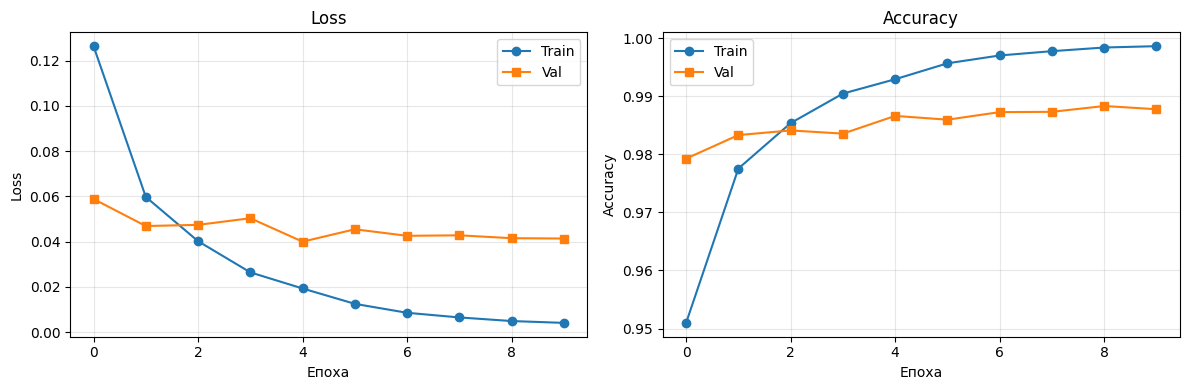

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train', marker='o')
ax1.plot(history['val_loss'],   label='Val',   marker='s')
ax1.set_title('Loss')
ax1.set_xlabel('Епоха'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history['train_acc'], label='Train', marker='o')
ax2.plot(history['val_acc'],   label='Val',   marker='s')
ax2.set_title('Accuracy')
ax2.set_xlabel('Епоха'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_history.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Фінальна оцінка на тестовій вибірці

Завантажуємо найкращий чекпоінт і обчислюємо повний набір метрик.
**Positive class = FAKE** (тобто ми оцінюємо здатність системи виявити синтетичне зображення).


In [ ]:
checkpoint = torch.load(CONFIG['model_save_path'], map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Завантажено чекпоінт з епохи {checkpoint['epoch']}, val_acc={checkpoint['val_acc']:.4f}")

_, preds, labels, probs_fake = evaluate(model, test_loader, criterion, device)

# Бінарна перспектива з FAKE як позитивним класом
y_true_fake  = (labels == 0).astype(int)
y_pred_fake  = (preds  == 0).astype(int)
y_score_fake = probs_fake

acc  = accuracy_score(labels, preds)
prec = precision_score(y_true_fake, y_pred_fake)
rec  = recall_score(y_true_fake, y_pred_fake)
f1   = f1_score(y_true_fake, y_pred_fake)
auc  = roc_auc_score(y_true_fake, y_score_fake)

print("\n" + "=" * 50)
print("РЕЗУЛЬТАТИ НА ТЕСТОВІЙ ВИБІРЦІ")
print("=" * 50)
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}  (positive=FAKE)")
print(f"Recall:    {rec:.4f}  (positive=FAKE)")
print(f"F1-score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")
print("=" * 50)

print("\nДетальний classification report:")
print(classification_report(labels, preds, target_names=train_dataset.classes, digits=4))


## 12. Confusion Matrix та ROC-крива

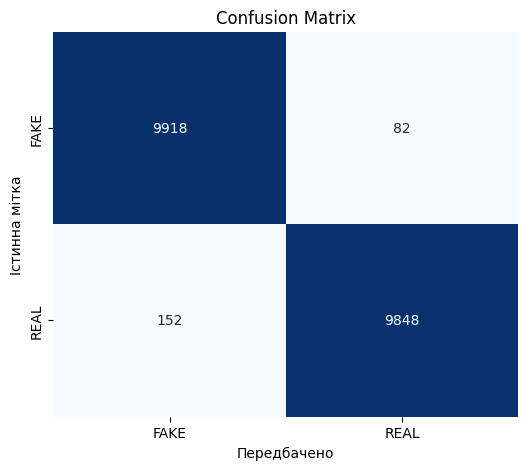

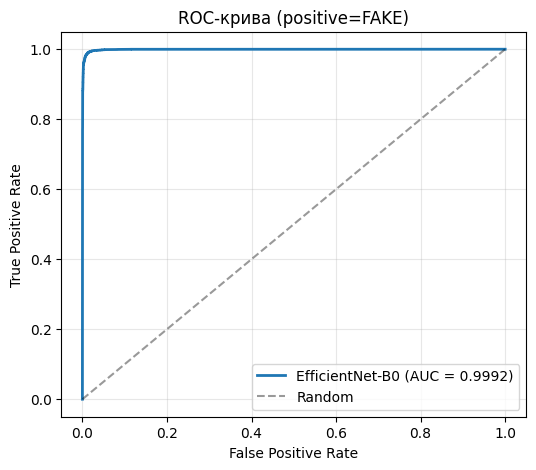

In [ ]:
# Confusion matrix
cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes, ax=ax, cbar=False)
ax.set_xlabel('Передбачено'); ax.set_ylabel('Істинна мітка')
ax.set_title('Confusion Matrix')
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_true_fake, y_score_fake)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f'EfficientNet-B0 (AUC = {auc:.4f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-крива (positive=FAKE)')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.savefig('/content/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()


## 13. Sanity check: інференс на кількох семплах

Швидкий візуальний контроль що модель прогнозує адекватно.


In [ ]:
import random
from PIL import Image

model.eval()
classes = train_dataset.classes  # ['FAKE', 'REAL']

# Беремо 8 випадкових прикладів з тесту
sample_indices = random.sample(range(len(test_dataset)), 8)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, idx in zip(axes.flat, sample_indices):
    img_tensor, true_label = test_dataset[idx]
    with torch.no_grad():
        out = model(img_tensor.unsqueeze(0).to(device))
        probs = torch.softmax(out, dim=1)[0]
        pred = out.argmax(dim=1).item()

    # Денормалізуємо для візуалізації
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = img * np.array(imagenet_std) + np.array(imagenet_mean)
    img = np.clip(img, 0, 1)

    color = 'green' if pred == true_label else 'red'
    ax.imshow(img)
    ax.set_title(
        f"True: {classes[true_label]}\n"
        f"Pred: {classes[pred]}  (P(FAKE)={probs[0].item():.2f})",
        color=color, fontsize=10
    )
    ax.axis('off')

plt.tight_layout()
plt.show()


## 14. Збереження артефактів та експорт у ONNX

ONNX-експорт корисний на випадок, якщо вирішимо запускати inference у Node.js
через `onnxruntime-node`


In [ ]:
!pip install -q onnxscript

# Експорт у ONNX
model.eval()
dummy_input = torch.randn(1, 3, CONFIG['image_size'], CONFIG['image_size']).to(device)
torch.onnx.export(
    model, dummy_input, CONFIG['onnx_save_path'],
    input_names=['input'],
    output_names=['logits'],
    dynamic_axes={'input': {0: 'batch'}, 'logits': {0: 'batch'}},
    opset_version=14
)
print(f"ONNX збережено: {CONFIG['onnx_save_path']}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 13.3 MB/s eta 0:00:00


/tmp/ipykernel_6681/1020051006.py:6: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0507 19:47:36.960000 6681 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 14 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0507 19:47:38.151000 6681 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = 

[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:68: adapt: Asserti

[torch.onnx] Translate the graph into ONNX... ✅
ONNX збережено: /content/efficientnet_b0_synthdetect.onnx


In [ ]:
from google.colab import files

files.download(CONFIG['model_save_path'])      # .pth — для Python ML-сервісу
files.download(CONFIG['onnx_save_path'])       # .onnx — резерв на ONNX-варіант
files.download('/content/training_history.png')
files.download('/content/confusion_matrix.png')
files.download('/content/roc_curve.png')


Завантажуємо артефакти на твій комп'ютер:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
